# Neutrino Oscillation Simulation
 This notebook simulates the survival probability of reactor electron antineutrinos ($\bar{\nu}_e$) at the Jiangmen Underground Neutrino Observatory (JUNO). JUNO is a medium‑baseline reactor experiment with a baseline of approximately **52.5 km**, designed to determine the neutrino mass ordering (sign of $\Delta m^2_{31}$) and to measure oscillation parameters with sub‑percent precision.

 The survival probability for $\bar{\nu}_e \to \bar{\nu}_e$ in vacuum is:

 $$
 P_{ee} = 1 - \cos^4\theta_{13}\sin^2 2\theta_{12}\sin^2\Delta_{21}
          - \sin^2 2\theta_{13}\left(\cos^2\theta_{12}\sin^2\Delta_{31} + \sin^2\theta_{12}\sin^2\Delta_{32}\right)
 $$
 where $\Delta_{ij} = \Delta m^2_{ij} L / (4E)$, $L$ is the baseline, and $E$ is the antineutrino energy. Matter effects are small for JUNO but are included as an option using a constant‑density approximation.

This Jupyter notebook simulates the propagation and flavor evolution of solar neutrinos within the Sun and their subsequent detection at Earth, focusing on the three-flavor oscillation framework including the Mikheyev–Smirnov–Wolfenstein (MSW) matter effect. It defines physical constants, the solar density profile, and the matter potential, then constructs the flavor-basis Hamiltonian using a real PMNS matrix (with CP phase set to zero) and the latest neutrino mixing parameters. The evolution from the solar core to the surface is performed using a robust fixed-step first-order Magnus expansion (piecewise constant Hamiltonian), avoiding the stiffness issues of adaptive ODE solvers. The code calculates both instantaneous survival probabilities inside the Sun and averaged probabilities at Earth for all three flavors (νe -> νe, νμ, ντ), compares the numerical Pee with a two-flavour analytic MSW approximation, and generates two plots: one showing the averaged probabilities versus neutrino energy (0.1–100 MeV) and another depicting the radial survival probability of a 10 MeV neutrino as a function of solar radius fraction. The simulation outputs are saved as PNG images and demonstrate the energy-dependent transition from low-energy (≈0.55 survival) to high-energy (≈0.31 survival) solar neutrinos, consistent with standard MSW predictions.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.constants import physical_constants
from scipy.interpolate import interp1d
from pathlib import Path
from scipy.linalg import expm

Solar neutrino oscillation simulation (νe → νμ, ντ)

Propagating a 10.0 MeV νe through the Sun (Magnus method)...
At Earth (averaged):
  P(νe → νe)  = 0.3102
  P(νe → νμ)  = 0.2844
  P(νe → ντ)  = 0.4054
  Sum         = 1.0000

Computing survival probability for a range of energies...
  Completed 10/40 energies
  Completed 20/40 energies
  Completed 30/40 energies
  Completed 40/40 energies


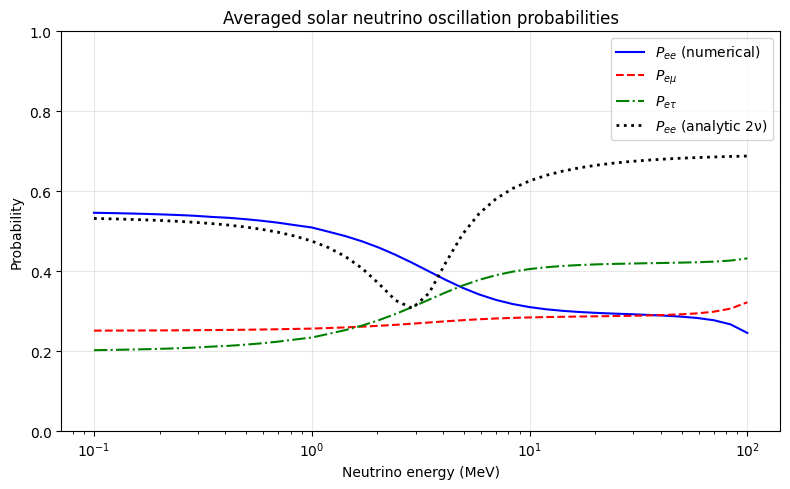


Computing radial survival probability for 10.0 MeV (Magnus method)...


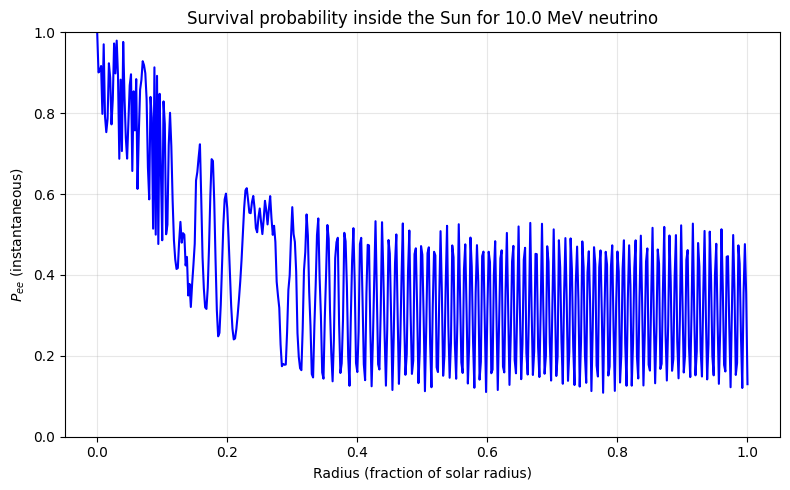


Simulation complete. Plots saved as 'solar_neutrino_probabilities.png'
and 'solar_neutrino_radial.png'.


In [ ]:
# Physical constants and unit conversions

G_F = 1.1663787e-23          # Fermi constant in eV^-2
hbar_c_eV_m = 1.973269631e-7 # hbarc in eV·m
cm_to_eVinv = 1.0 / (hbar_c_eV_m * 100)   # 1 cm = 5.0677e4 eV^-1

R_sun_cm = 6.957e10          # solar radius in cm
R0_cm = R_sun_cm / 10.54     # density scale height
rho0 = 150.0                 # central density g/cm^3
Ye = 0.8                     # electron fraction

# Neutrino mixing parameters (three-flavour, normal mass ordering)

s2_12 = 0.307
s2_13 = 0.022
s2_23 = 0.5
theta12 = np.arcsin(np.sqrt(s2_12))
theta13 = np.arcsin(np.sqrt(s2_13))
theta23 = np.arcsin(np.sqrt(s2_23))
delta_cp = 0.0

dm21 = 7.53e-5               # eV^2
dm31 = 2.525e-3              # eV^2
dm32 = dm31 - dm21

# PMNS matrix – real because delta_cp = 0
c12, s12 = np.cos(theta12), np.sin(theta12)
c13, s13 = np.cos(theta13), np.sin(theta13)
c23, s23 = np.cos(theta23), np.sin(theta23)

U = np.array([
    [c12*c13,                s12*c13,                s13],
    [-s12*c23 - c12*s23*s13, c12*c23 - s12*s23*s13, s23*c13],
    [s12*s23 - c12*c23*s13,  -c12*s23 - s12*c23*s13, c23*c13]
])

# Solar density and matter potential

def density_profile(r_cm):
    """Solar mass density (g/cm^3) at radius r (cm)."""
    return rho0 * np.exp(-r_cm / R0_cm)

def matter_potential(r_cm):
    """
    Matter potential V = sqrt(2) * G_F * Ne (eV).
    Ne = Ye * rho * N_A (electron number density in cm^-3), converted to eV^3.
    """
    N_A = 6.02214076e23   # mol^-1
    Ne_cm3 = Ye * density_profile(r_cm) * N_A
    Ne_eV3 = Ne_cm3 * (cm_to_eVinv**-3)   # 1 cm^-3 = (cm_to_eVinv)^-3 eV^3
    return np.sqrt(2.0) * G_F * Ne_eV3

# Hamiltonian in flavour basis (real symmetric)

def hamiltonian_flavour(E_eV, x_eVinv):
    """
    Flavour‑basis Hamiltonian H_f (eV) at energy E (eV) and position x (eV^-1).
    H_f = (1/(2E)) U * diag(0, dm21, dm31) * U.T + diag(V, 0, 0)
    """
    r_cm = x_eVinv / cm_to_eVinv
    V = matter_potential(r_cm)

    M2 = np.diag([0.0, dm21, dm31])
    H_vac = (1.0 / (2.0 * E_eV)) * (U @ M2 @ U.T)
    H_mat = np.diag([V, 0.0, 0.0])
    return H_vac + H_mat

# Propagation via fixed‑step Magnus expansion

def propagate_magnus(E_eV, N_steps=20000):
    """
    Solve the Schrödinger equation from solar centre to surface using the
    first-order Magnus expansion with piecewise constant Hamiltonian.
    Returns the final state ψ_surface (complex 3-vector).
    """
    L = R_sun_cm * cm_to_eVinv    # total distance in eV^-1
    dx_scaled = 1.0 / N_steps     # step size in scaled variable
    psi = np.array([1.0 + 0j, 0.0 + 0j, 0.0 + 0j])   # start as νe

    for i in range(N_steps):
        # Midpoint of the interval in scaled coordinates
        x_mid = (i + 0.5) * dx_scaled
        x_eVinv = x_mid * L
        H = hamiltonian_flavour(E_eV, x_eVinv)   # real symmetric
        # Propagation matrix for this step: exp(-i * L * H * dx_scaled)
        U_step = expm(-1j * L * H * dx_scaled)
        psi = U_step @ psi

    return psi

def propagate_magnus_with_radial(E_eV, N_steps=50000, save_every=100):
    """
    propagate and save the survival probability at selected radial points.
    returns arrays: r_frac (fraction of solar radius), P_ee (instantaneous).
    """
    L = R_sun_cm * cm_to_eVinv
    dx_scaled = 1.0 / N_steps
    psi = np.array([1.0 + 0j, 0.0 + 0j, 0.0 + 0j])

    # Pre‑allocate storage
    n_save = N_steps // save_every + 1
    r_frac = np.zeros(n_save)
    P_ee = np.zeros(n_save)

    # Save initial point
    r_frac[0] = 0.0
    P_ee[0] = np.abs(psi[0])**2
    save_idx = 1

    for i in range(N_steps):
        x_mid = (i + 0.5) * dx_scaled
        x_eVinv = x_mid * L
        H = hamiltonian_flavour(E_eV, x_eVinv)
        U_step = expm(-1j * L * H * dx_scaled)
        psi = U_step @ psi

        # Save every `save_every` steps
        if (i + 1) % save_every == 0:
            r_frac[save_idx] = (i + 1) * dx_scaled
            P_ee[save_idx] = np.abs(psi[0])**2
            save_idx += 1

    return r_frac, P_ee

# Averaged probabilities at Earth

def averaged_probabilities(psi_surface):
    """Compute P(νe -> να) after vacuum averaging."""
    psi_mass = U.T @ psi_surface   # U is real, so U† = U.T
    P = np.zeros(3)
    for alpha in range(3):
        P[alpha] = np.sum(np.abs(U[alpha, :])**2 * np.abs(psi_mass)**2)
    return P   # [P_ee, P_eμ, P_eτ]

# Analytic MSW survival probability

def analytic_msw_survival(E_MeV):
    """
    Simple two-flavour adiabatic MSW survival probability.
    Returns P_ee for given energy in MeV.
    """
    E_eV = E_MeV * 1e6
    dm2 = dm21
    sin2_theta = s2_12
    cos2_theta = 1 - sin2_theta
    V_prod = matter_potential(0.0)   # central potential
    A = 2 * E_eV * V_prod / dm2
    sin2_theta_m = sin2_theta / np.sqrt((A - cos2_theta)**2 + sin2_theta**2)
    P_jump = 0.0   # adiabatic approximation
    P_ee = 0.5 + (0.5 - P_jump) * np.cos(2*theta12) * np.cos(2*np.arcsin(np.sqrt(sin2_theta_m)))
    return P_ee

# Main simulation

def main():
    print("Solar neutrino oscillation simulation (νe \u2192 νμ, ντ)")
    print("=" * 60)

    # Single energy example (8B neutrinos, ~10 MeV)
    E_MeV = 10.0
    E_eV = E_MeV * 1e6
    print(f"\nPropagating a {E_MeV} MeV νe through the Sun (Magnus method)...")
    psi_surface = propagate_magnus(E_eV, N_steps=20000)
    P = averaged_probabilities(psi_surface)
    print(f"At Earth (averaged):")
    print(f"  P(νe \u2192 νe)  = {P[0]:.4f}")
    print(f"  P(νe \u2192 νμ)  = {P[1]:.4f}")
    print(f"  P(νe \u2192 ντ)  = {P[2]:.4f}")
    print(f"  Sum         = {np.sum(P):.4f}")

    # Survival probability vs energy
    energies_MeV = np.logspace(-1, 2, 40)   # 0.1 – 100 MeV
    P_ee = np.zeros_like(energies_MeV)
    P_emu = np.zeros_like(energies_MeV)
    P_etau = np.zeros_like(energies_MeV)

    print("\nComputing survival probability for a range of energies...")
    for i, E_MeV in enumerate(energies_MeV):
        E_eV = E_MeV * 1e6
        psi_surface = propagate_magnus(E_eV, N_steps=20000)
        P = averaged_probabilities(psi_surface)
        P_ee[i] = P[0]
        P_emu[i] = P[1]
        P_etau[i] = P[2]
        if (i+1) % 10 == 0:
            print(f"  Completed {i+1}/{len(energies_MeV)} energies")

    # Plot
    plt.figure(figsize=(8, 5))
    plt.semilogx(energies_MeV, P_ee, 'b-', label=r'$P_{ee}$ (numerical)')
    plt.semilogx(energies_MeV, P_emu, 'r--', label=r'$P_{e\mu}$')
    plt.semilogx(energies_MeV, P_etau, 'g-.', label=r'$P_{e\tau}$')
    P_ee_analytic = np.array([analytic_msw_survival(E) for E in energies_MeV])
    plt.semilogx(energies_MeV, P_ee_analytic, 'k:', lw=2, label=r'$P_{ee}$ (analytic 2ν)')
    plt.xlabel('Neutrino energy (MeV)')
    plt.ylabel('Probability')
    plt.title('Averaged solar neutrino oscillation probabilities')
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('solar_neutrino_probabilities.png', dpi=150)
    plt.show()

    # Radial evolution of P_ee inside the Sun for a fixed energy
    E_fixed_MeV = 10.0
    E_fixed_eV = E_fixed_MeV * 1e6
    print(f"\nComputing radial survival probability for {E_fixed_MeV} MeV (Magnus method)...")

    r_frac, P_ee_radial = propagate_magnus_with_radial(E_fixed_eV,
                                                       N_steps=50000,
                                                       save_every=100)
    plt.figure(figsize=(8, 5))
    plt.plot(r_frac, P_ee_radial, 'b-')
    plt.xlabel('Radius (fraction of solar radius)')
    plt.ylabel(r'$P_{ee}$ (instantaneous)')
    plt.title(f'Survival probability inside the Sun for {E_fixed_MeV} MeV neutrino')
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('solar_neutrino_radial.png', dpi=150)
    plt.show()

    print("\nSimulation complete. Plots saved as 'solar_neutrino_probabilities.png'")
    print("and 'solar_neutrino_radial.png'.")

if __name__ == "__main__":
    main()